# 01 — Explore trades

Pull a bounded window into a DataFrame and look at it. Everything here is
read-only and local; nothing writes back to Kafka.

Prerequisites are the same as `00_stream_health.ipynb`.

In [1]:
import matplotlib.pyplot as plt

import devlab
from devlab import frames

target = devlab.resolve()
target

Target(name='local', bootstrap='127.0.0.1:9092', sasl_username=None)

## Grab a window

`collect()` is bounded by **both** a message count and a wall clock, whichever
comes first — so this cell always returns, even against a dead broker.

`offset_reset="earliest"` reads what is already retained. Use `"latest"` to
watch only what arrives from now on.

In [2]:
records = devlab.collect(target, limit=20_000, seconds=60.0, offset_reset="earliest")
df = frames.trades_frame(records)
print(f"{len(df):,} trades  {df['event_ts'].min()} .. {df['event_ts'].max()}")
df.head()

4,730 trades  2026-08-09 08:19:35.203341+00:00 .. 2026-08-09 14:24:35.180000+00:00


,event_ts,ingest_ts,venue,venue_symbol,instrument_id,trade_id,price,size,notional,side,...,is_backfill,latency_ms,price_str,size_str,kafka_partition,kafka_offset,event_ts_us,ingest_ts_us,kafka_timestamp_ms,kafka_key
0,2026-08-09 08:19:35.203341+00:00,2026-08-09 08:38:52.843714+00:00,coinbase,AVAX-USD,AVAX-USD,68942358,6.481,12.300000,79.7163,BUY,...,False,1157640.373,6.481,12.29999999,5,199,1786263575203341,1786264732843714,1786264732850,coinbase|AVAX-USD
1,2026-08-09 08:19:35.203341+00:00,2026-08-09 08:38:55.411050+00:00,coinbase,AVAX-USD,AVAX-USD,68942358,6.481,12.300000,79.7163,BUY,...,True,1160207.709,6.481,12.29999999,5,399,1786263575203341,1786264735411050,1786264735755,coinbase|AVAX-USD
2,2026-08-09 08:19:51.152732+00:00,2026-08-09 08:38:52.843711+00:00,coinbase,AVAX-USD,AVAX-USD,68942359,6.481,12.300000,79.7163,BUY,...,False,1141690.979,6.481,12.3,5,198,1786263591152732,1786264732843711,1786264732850,coinbase|AVAX-USD
3,2026-08-09 08:19:51.152732+00:00,2026-08-09 08:38:55.411048+00:00,coinbase,AVAX-USD,AVAX-USD,68942359,6.481,12.300000,79.7163,BUY,...,True,1144258.316,6.481,12.3,5,398,1786263591152732,1786264735411048,1786264735755,coinbase|AVAX-USD
4,2026-08-09 08:20:20.410728+00:00,2026-08-09 08:38:55.411046+00:00,coinbase,AVAX-USD,AVAX-USD,68942360,6.481,0.152754,0.9900,SELL,...,True,1115000.318,6.481,0.1527542,5,397,1786263620410728,1786264735411046,1786264735755,coinbase|AVAX-USD


Prices and sizes cross the wire as **strings** so no precision is lost in
transit. `trades_frame` converts them to float64 for arithmetic and plotting
and keeps the exact originals in `price_str` / `size_str` — check those when a
number looks wrong.

In [4]:
df[["venue", "instrument_id", "price", "size", "notional", "side", "latency_ms"]].describe()

,price,size,notional,latency_ms
count,10068.000000,1.006800e+04,1.006800e+04,1.006800e+04
mean,15938.319702,6.192988e+02,8.216536e+02,9.351118e+04
std,27491.626842,4.757385e+03,4.917519e+03,3.051556e+05
min,0.070010,1.000000e-08,6.484000e-08,-1.793270e+02
25%,1.047200,1.327447e-03,2.690480e+00,-8.664450e+01
50%,76.330000,1.440000e-01,4.029432e+01,2.908850e+01
75%,1921.940000,2.045005e+01,3.518657e+02,3.012490e+04
max,65060.860000,2.474740e+05,1.308240e+05,4.305364e+06


## Who is producing what

In [5]:
frames.frame(
    df.groupby(["venue", "instrument_id"], observed=True)
    .agg(trades=("trade_id", "count"), volume=("size", "sum"), notional=("notional", "sum"))
    .reset_index()
    .sort_values("notional", ascending=False)
    .to_dict("records")
)

,venue,instrument_id,trades,volume,notional
0,coinbase,BTC-USD,1331,4.230904e+01,2.749912e+06
1,binance,BTC-USD,1075,2.211637e+01,1.438300e+06
2,binance,SOL-USD,828,1.552866e+04,1.184015e+06
3,binance,ETH-USD,782,4.141931e+02,7.959496e+05
4,coinbase,XRP-USD,921,3.771131e+05,3.939326e+05
5,coinbase,SOL-USD,1017,5.112534e+03,3.893189e+05
6,binance,XRP-USD,268,2.756984e+05,2.885725e+05
7,coinbase,ETH-USD,1290,1.089920e+02,2.093262e+05
8,coinbase,DOGE-USD,505,2.934709e+06,2.067252e+05
9,coinbase,ADA-USD,522,9.898029e+05,1.972599e+05


## Price over the window

One line per instrument, each on its own axis — BTC and DOGE on a shared scale
tells you nothing.

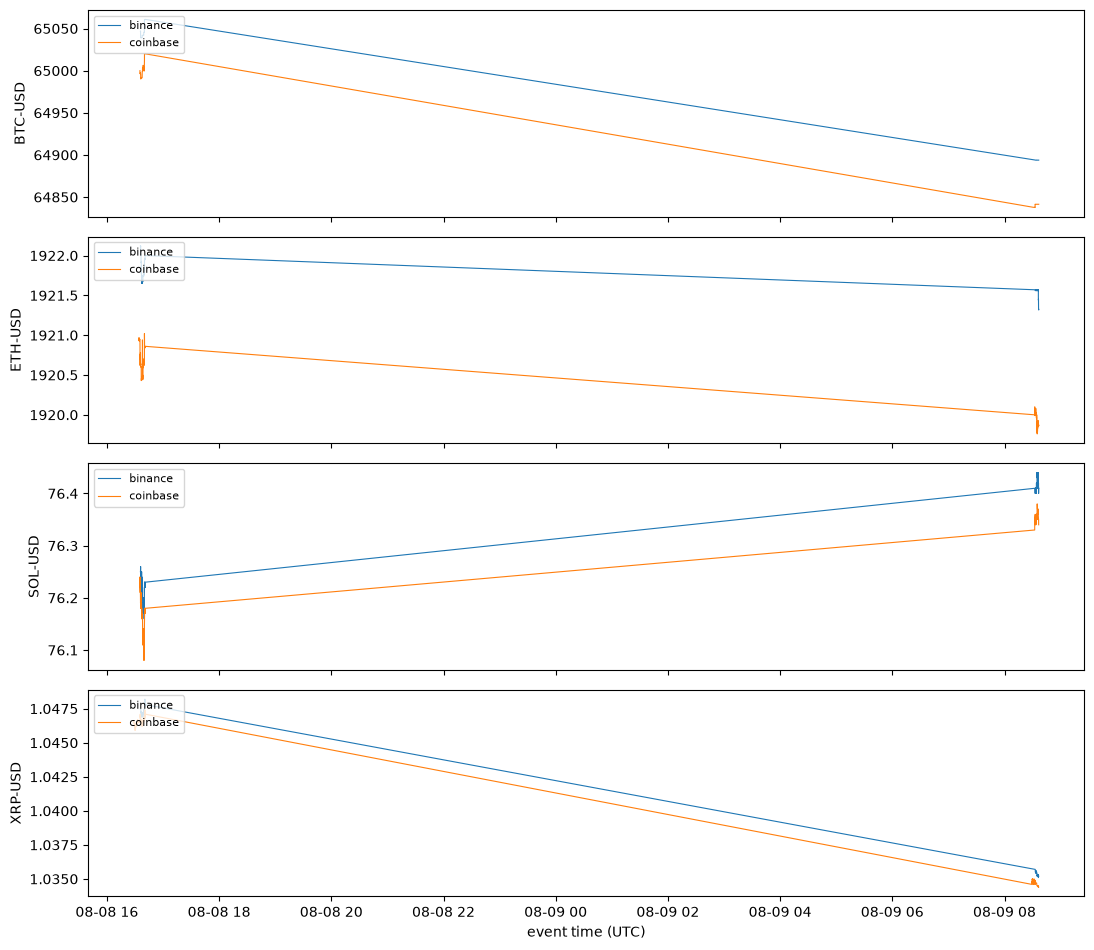

In [9]:
instruments = df["instrument_id"].value_counts().head(4).index.tolist()
fig, axes = plt.subplots(
    len(instruments), 1, figsize=(11, 2.4 * len(instruments)), sharex=True, squeeze=False
)
for axis, instrument in zip(axes.ravel(), instruments, strict=True):
    for venue, group in df[df["instrument_id"] == instrument].groupby("venue", observed=True):
        axis.plot(group["event_ts"], group["price"], linewidth=0.8, label=venue)
    axis.set_ylabel(instrument)
    axis.legend(loc="upper left", fontsize=8)
axes.ravel()[-1].set_xlabel("event time (UTC)")
fig.tight_layout()

## Ingest latency

`ingest_ts - event_ts`: how long between the exchange stamping the trade and
this process seeing it. Includes exchange-side delay, network, and our own
parse time, so read it as an upper bound rather than a network measurement.

A long right tail usually means the bounded queue was saturating.

KeyError: "['90%'] not in index"

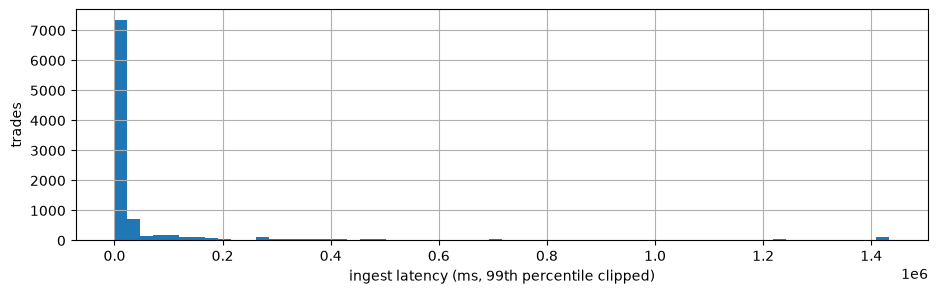

In [8]:
axis = df["latency_ms"].clip(upper=df["latency_ms"].quantile(0.99)).hist(bins=60, figsize=(11, 3))
axis.set_xlabel("ingest latency (ms, 99th percentile clipped)")
axis.set_ylabel("trades")
print(df.groupby("venue", observed=True)["latency_ms"].describe()[["50%", "90%", "max"]])

## Do the two venues agree

Same instrument, same minute, VWAP on each venue and the spread between them.
Persistent non-zero spread is normal — different venues, different order books.
A spread that trends is worth a second look.

In [ ]:
comparison = frames.venue_comparison(df, freq="1min")
comparison.tail(10)

In [ ]:
btc = comparison[comparison["instrument_id"] == "BTC-USD"]
if "spread_bps" in btc.columns and not btc.empty:
    axis = btc.plot(x="event_ts", y="spread_bps", figsize=(11, 3), legend=False)
    axis.axhline(0, color="black", linewidth=0.6)
    axis.set_ylabel("binance - coinbase (bps)")
else:
    print("need both venues in the window for a spread")